## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load CSV file

In [2]:
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

## Check the first rows

In [3]:
df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


## Check dataset size

In [4]:
df.shape

(9011, 2)

## Check column names

In [5]:
df.columns

Index(['Date', 'Price'], dtype='str')

## Convert Date column

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\admin\AppData\Local\Temp\ipykernel_13112\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


## Set Date as index

In [8]:
df = df.set_index('Date')

## Check missing values

In [10]:
df.isnull().sum()

Price    0
dtype: int64

## Statistical summary

In [11]:
df.describe()

,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


## Exploratory Data Analysis (EDA)

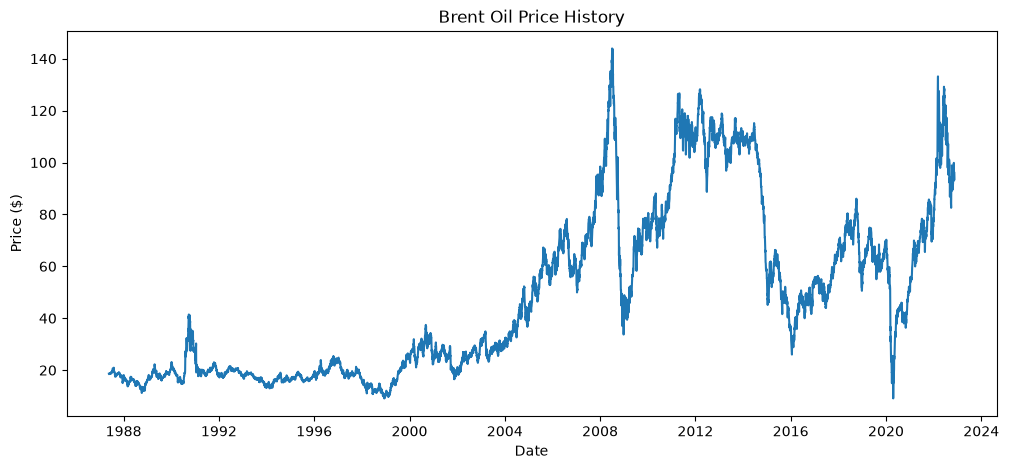

In [12]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Price'])

plt.title("Brent Oil Price History")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

Brent Oil Price Historical Trend

The plot above shows the historical movement of Brent crude oil prices over time.

Key observations:

- The x-axis represents the date, while the y-axis represents the Brent oil price in US dollars per barrel.
- Oil prices show significant fluctuations over the historical period, indicating periods of high and low market volatility.
- Several major price movements can be observed, which may correspond to important global events:
  - The 2008 financial crisis caused a sharp decline in oil prices.
  - The 2014–2016 oil oversupply period led to a significant price drop.
  - The 2020 COVID-19 pandemic created an extreme fall in oil demand and prices.
  - The 2022 energy crisis contributed to a strong increase in oil prices.

These sudden changes suggest possible structural shifts in the oil market. 
Change point analysis will be used to identify the dates where the statistical behavior of Brent oil prices changed significantly.

Price Distribution (Histogram)

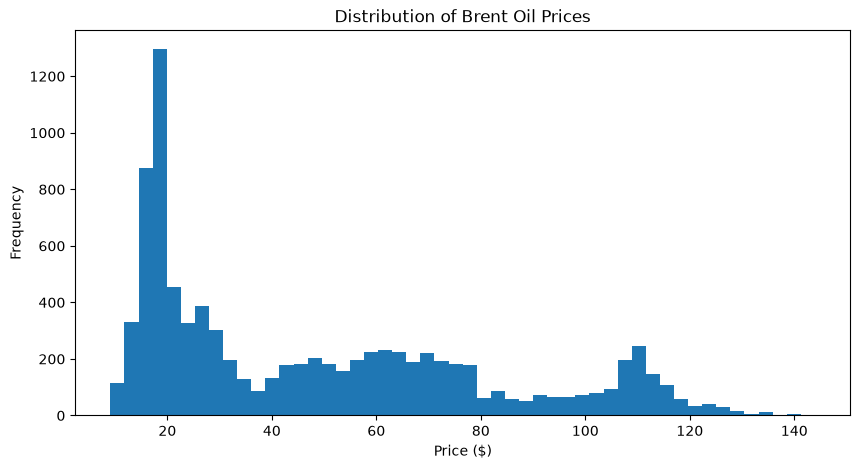

In [13]:
plt.figure(figsize=(10,5))

plt.hist(df['Price'], bins=50)

plt.title("Distribution of Brent Oil Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")

plt.show()

 Brent Oil Price Distribution

The histogram shows the distribution of Brent oil prices over the historical period.

- The distribution helps identify the range where prices occur most frequently.
- The shape of the distribution indicates whether prices are symmetric or skewed.
- Extreme price periods may create a skewed distribution due to major market events.

Boxplot (Outlier Detection)

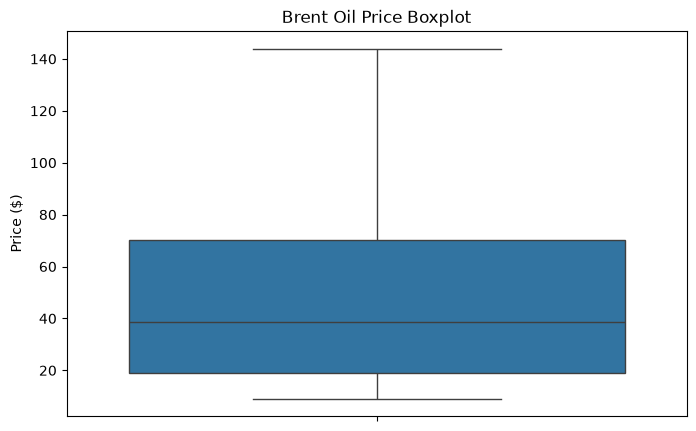

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['Price'])

plt.title("Brent Oil Price Boxplot")
plt.ylabel("Price ($)")

plt.show()

Brent Oil Price Outlier Analysis

The boxplot highlights the spread and extreme values of Brent oil prices.

- The box represents the main range of observed prices.
- Points outside the range indicate potential outliers.
- These extreme values may correspond to significant market events rather than data errors.

Rolling Mean (Long-term Trend)

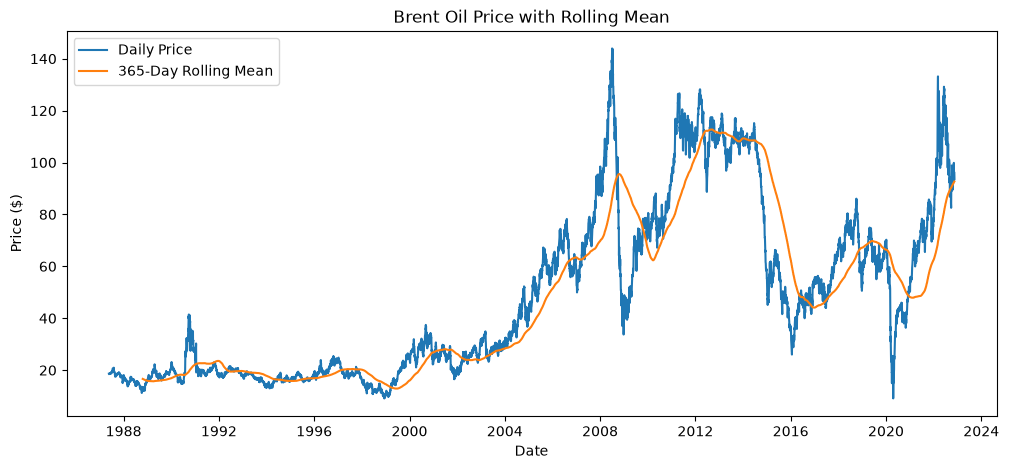

In [15]:
df['Rolling_Mean'] = df['Price'].rolling(window=365).mean()


plt.figure(figsize=(12,5))

plt.plot(df.index, df['Price'], label="Daily Price")
plt.plot(df.index, df['Rolling_Mean'], label="365-Day Rolling Mean")

plt.title("Brent Oil Price with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.legend()
plt.show()

 Brent Oil Price Rolling Mean Analysis

The rolling mean smooths daily price fluctuations to reveal the long-term trend.

- The daily price line shows short-term movements and volatility.
- The 365-day rolling mean highlights overall market direction.
- Changes in the rolling trend may indicate possible structural changes in the oil market.

## Trend Analysis

### Observations

- Brent oil prices show significant fluctuations over time.
- The historical trend includes periods of price increases, sharp declines, and recoveries.
- The histogram indicates that prices are not perfectly symmetric and may be slightly skewed.
- The boxplot reveals several extreme values, suggesting periods of unusually high or low prices.
- The 365-day rolling mean highlights the long-term trend while smoothing short-term fluctuations.

These observations suggest that the Brent oil market has experienced structural changes, making it suitable for change point analysis.

## Stationarity

### Augmented Dickey-Fuller (ADF) Test

In [16]:
from statsmodels.tsa.stattools import adfuller

In [17]:
result = adfuller(df['Price'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.9938560113924675
p-value: 0.28927350489340287
Critical Values:
1%: -3.4310783342658615
5%: -2.861861876398633
10%: -2.566941329781918


In [18]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

The series is not stationary.


### Not Stationarity Test (ADF)

The Augmented Dickey-Fuller (ADF) test was used to assess the not stationarity of the Brent oil price series.

- The p-value is greater than 0.05.
- Therefore, the null hypothesis cannot be rejected.
- The Brent oil price series is **not stationary**, indicating that its statistical properties change over time.

## Volatility

In [19]:
import numpy as np

df['Log_Return'] = np.log(df['Price'] / df['Price'].shift(1))

df.head()

,Price,Rolling_Mean,Log_Return
Date,,,
1987-05-20,18.63,NaN,NaN
1987-05-21,18.45,NaN,-0.009709
1987-05-22,18.55,NaN,0.005405
1987-05-25,18.60,NaN,0.002692
1987-05-26,18.63,NaN,0.001612


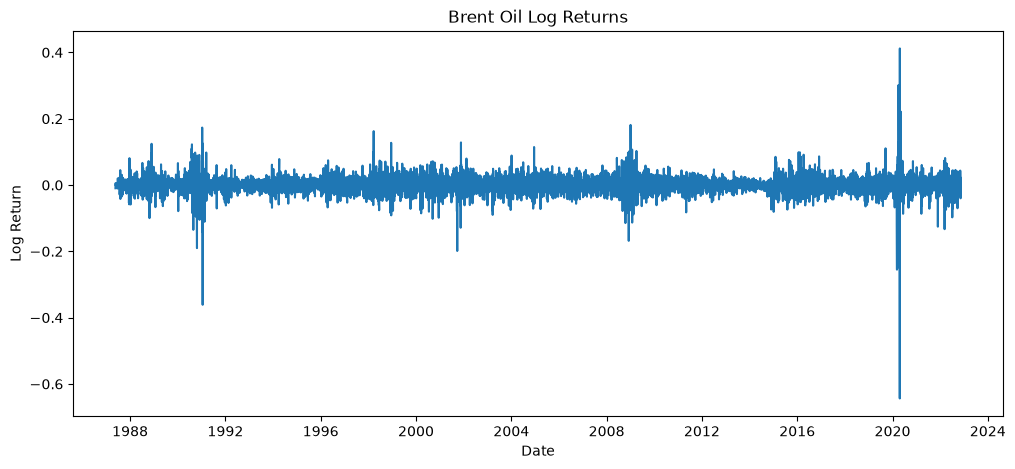

In [20]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Log_Return'])

plt.title("Brent Oil Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.show()

 Volatility Analysis

Log returns were computed to measure daily percentage changes in Brent oil prices. The log return plot shows periods of both stable and highly volatile market behavior. The 30-day rolling volatility highlights intervals of increased price fluctuations, which may correspond to significant economic or geopolitical events. Overall, volatility is not constant over time, indicating changing market conditions.

## Research Events

In [24]:
events = pd.read_csv("../data/raw/events.csv")

events

,Date,Event
0,1990-08-02,Gulf War
1,1997-07-02,Asian Financial Crisis
2,2001-09-11,9/11 Terrorist Attacks
3,2003-03-20,Iraq War
4,2008-09-15,Global Financial Crisis
5,2010-12-17,Arab Spring Begins
6,2014-06-20,Oil Price Crash
7,2016-11-30,OPEC Production Cut Agreement
8,2020-03-11,COVID-19 Pandemic Declared
9,2020-04-20,Historic Oil Price Collapse


 Research Events

A dataset of major geopolitical and economic events was created and saved as `data/raw/events.csv`. These events include wars, financial crises, OPEC production decisions, and the COVID-19 pandemic. This dataset will be used later to relate structural changes in Brent oil prices to real-world events.

## Write Analysis Workflow

An analysis plan was prepared to define the project workflow. The process includes data loading, exploratory data analysis, trend analysis, stationarity testing, volatility analysis, historical event research, Bayesian change point modeling, interpretation of results, and dashboard development.

## Project Assumptions

The analysis assumes that event dates are approximate and that Brent oil prices are affected by many external factors. While historical events may coincide with price changes, correlation does not imply causation. The Bayesian model identifies statistical change points rather than proving the exact causes of market movements.

## Change Point Model Notes

### What is a Change Point?

A change point is a point in time where the statistical behavior of a time series changes significantly. In Brent oil prices, it can represent a shift in price patterns caused by major economic, political, or global events.

### Why Use Bayesian Methods?

Bayesian change point analysis estimates the probability of changes in a time series and provides uncertainty around the estimated change points. It helps identify when the behavior of oil prices changed.

### Expected Model Output

The model will produce:

- Estimated change point dates
- Probability of each change point
- Price behavior before and after the change point

### Limitations

- The model identifies statistical changes, not the exact causes.
- Change points may not always match real-world events.
- Results depend on model assumptions and prior choices.
- Other factors affecting oil prices may not be included.